# Dimensionality Reduction: Kernel PCA for TF-IDF

This notebook adds a **nonlinear projection baseline** for TF-IDF emotion classification.

What it does:
- loads the TF-IDF feature CSV
- separates metadata from model features
- trains baseline classifiers on the original TF-IDF features
- compresses TF-IDF with `TruncatedSVD`
- applies `KernelPCA` on the dense SVD projection to surface nonlinear structure
- retrains the same models on the nonlinear projection
- saves Kernel PCA component names and transformed datasets


## 1) Imports and Notebook Settings

This cell sets up dependencies and plotting style.

In [1]:
from pathlib import Path
import json
import os
import sys
from contextlib import contextmanager

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.decomposition import KernelPCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from joblib import Parallel, delayed
from tqdm.auto import tqdm

plt.style.use('ggplot')
np.random.seed(42)

print('Imports loaded.')


Imports loaded.


## 2) Configuration

This notebook is specialized for TF-IDF and writes its artifacts under a distinct dataset key so it does not overwrite the linear TF-IDF PCA run.


In [2]:
REPO_ROOT = Path.cwd().resolve().parents[2] if 'feature_selection' in str(Path.cwd()) else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from feature_selection.common import (
    DEFAULT_EXCLUDED_EMOTIONS,
    DEFAULT_REQUIRE_AGREEMENT,
    METADATA_CANDIDATES,
    filter_feature_frame,
    include_xxx_from_env,
    machine_name_from_env,
    resolve_cpu_parallel_config,
    resolve_feature_source,
    resolve_pca_artifact_dir,
    resolve_pca_component_count,
    resolve_random_forest_jobs,
    use_variant_artifact_dirs_from_env,
    variant_name,
)

DATASET_KEY = 'tfidf_kernel_pca'
SOURCE_DATASET_KEY = 'tfidf'
TARGET_COL = 'emotion'
TEST_SIZE = 0.20
RANDOM_STATE = 42
SVD_COMPONENTS = 512
KERNEL_PCA_COMPONENTS = 192
KERNEL = 'rbf'
KERNEL_GAMMA = None
KERNEL_DEGREE = 3
KERNEL_COEF0 = 1.0
DECOMPOSITION_METHOD = 'truncated_svd_plus_kernel_pca'
USE_NROWS = None
REQUIRE_AGREEMENT = DEFAULT_REQUIRE_AGREEMENT
EXCLUDED_EMOTIONS = DEFAULT_EXCLUDED_EMOTIONS

MACHINE_NAME = machine_name_from_env()
INCLUDE_XXX = include_xxx_from_env(default=True)
VARIANT_NAME = variant_name(INCLUDE_XXX)
USE_VARIANT_ARTIFACT_DIRS = use_variant_artifact_dirs_from_env(default=True)
MODEL_PARALLEL_JOBS, MODEL_PARALLEL_MODE = resolve_cpu_parallel_config(MACHINE_NAME)
RANDOM_FOREST_JOBS = resolve_random_forest_jobs(MACHINE_NAME)

source_path = resolve_feature_source(REPO_ROOT, DATASET_KEY)
artifact_dir = resolve_pca_artifact_dir(
    REPO_ROOT,
    include_xxx=INCLUDE_XXX,
    use_variant_dirs=USE_VARIANT_ARTIFACT_DIRS,
)

print(f'Repository root: {REPO_ROOT}')
print(f'Source dataset key: {SOURCE_DATASET_KEY}')
print(f'Artifact dataset key: {DATASET_KEY}')
print(f'Selected source: {source_path}')
print('Source exists:', source_path.exists())
print(f'Machine: {MACHINE_NAME}')
print(f'Include xxx: {INCLUDE_XXX} ({VARIANT_NAME})')
print(f'Artifact dir: {artifact_dir}')
print(f'CPU model parallel jobs: {MODEL_PARALLEL_JOBS} | mode={MODEL_PARALLEL_MODE}')
print(f'Decomposition method: {DECOMPOSITION_METHOD}')
print(f'SVD components (requested): {SVD_COMPONENTS}')
print(f'Kernel PCA components (requested): {KERNEL_PCA_COMPONENTS}')
print(f'Kernel: {KERNEL} | gamma={KERNEL_GAMMA} | degree={KERNEL_DEGREE} | coef0={KERNEL_COEF0}')


Repository root: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition
Source dataset key: tfidf
Artifact dataset key: tfidf_kernel_pca
Selected source: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/extracted_features/text/tfidf_features.csv
Source exists: True
Machine: macbook
Include xxx: True (with_xxx)
Artifact dir: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_with_xxx
CPU model parallel jobs: 1 | mode=sequential
Decomposition method: truncated_svd_plus_kernel_pca
SVD components (requested): 512
Kernel PCA components (requested): 192
Kernel: rbf | gamma=None | degree=3 | coef0=1.0


## 3) Load Data and Identify Feature Columns

This cell infers feature columns by excluding known metadata columns.

Rows loaded: 216
Rows after variant filtering: 216
Metadata columns (10): ['path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement', 'utt_id', 'text', 'split']
Feature columns (10480).
Sample feature columns: ['tfidf_00000', 'tfidf_00001', 'tfidf_00002', 'tfidf_00003', 'tfidf_00004', 'tfidf_00005', 'tfidf_00006', 'tfidf_00007', 'tfidf_00008', 'tfidf_00009']
Class distribution after filtering:
emotion
neu    68
fru    51
xxx    44
ang    33
sad    11
exc     5
hap     4
Name: count, dtype: int64


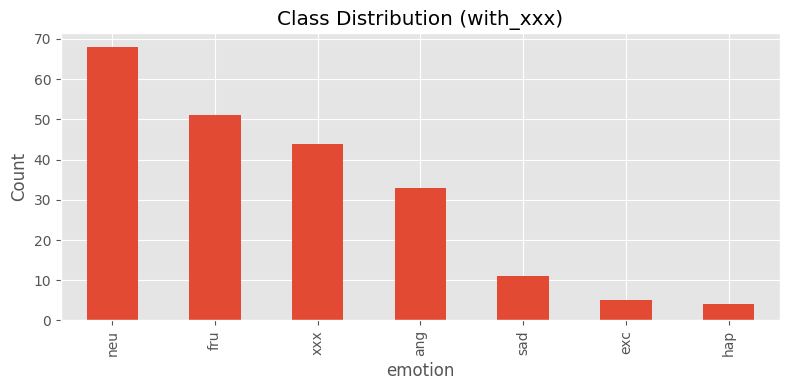

In [3]:
if not source_path.exists():
    raise FileNotFoundError(f'Missing source CSV: {source_path}')

raw_df = pd.read_csv(source_path, nrows=USE_NROWS)

if TARGET_COL not in raw_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available: {list(raw_df.columns[:20])}...")

rows_loaded = len(raw_df)
df = filter_feature_frame(
    raw_df,
    target_col=TARGET_COL,
    include_xxx=INCLUDE_XXX,
    require_agreement=REQUIRE_AGREEMENT,
    excluded_emotions=EXCLUDED_EMOTIONS,
)

meta_cols = [c for c in df.columns if c in METADATA_CANDIDATES]
feature_cols = [c for c in df.columns if c not in METADATA_CANDIDATES]

print(f'Rows loaded: {rows_loaded}')
print(f'Rows after variant filtering: {len(df)}')
print(f'Metadata columns ({len(meta_cols)}): {meta_cols}')
print(f'Feature columns ({len(feature_cols)}).')
print('Sample feature columns:', feature_cols[:10])

class_counts = df[TARGET_COL].value_counts(dropna=False)
print('Class distribution after filtering:')
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax)
ax.set_title(f'Class Distribution ({VARIANT_NAME})')
ax.set_xlabel(TARGET_COL)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4) Basic Cleaning and Train/Test Split

Rows with missing labels or missing feature values are removed.

In [4]:
model_df = df[[TARGET_COL] + feature_cols].copy()

rows_before = len(model_df)
model_df = model_df.dropna(subset=[TARGET_COL]).copy()
usable_feature_cols = [c for c in feature_cols if model_df[c].notna().all()]
dropped_feature_cols = [c for c in feature_cols if c not in usable_feature_cols]
model_df = model_df[[TARGET_COL] + usable_feature_cols].dropna(axis=0, how='any').copy()
rows_after = len(model_df)

X = model_df[usable_feature_cols].astype(float)
y_raw = model_df[TARGET_COL].astype(str)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning:  {rows_after}')
print(f'Dropped rows:         {rows_before - rows_after}')
print(f'Feature columns used: {len(usable_feature_cols)}')
print(f'Dropped feature columns with NaNs: {len(dropped_feature_cols)}')
if dropped_feature_cols:
    print('Sample dropped feature columns:', dropped_feature_cols[:10])
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Classes: {list(label_enc.classes_)}')


Rows before cleaning: 216
Rows after cleaning:  216
Dropped rows:         0
Feature columns used: 10480
Dropped feature columns with NaNs: 0
Train shape: (172, 10480)
Test shape:  (44, 10480)
Classes: ['ang', 'exc', 'fru', 'hap', 'neu', 'sad', 'xxx']


## 5) Baseline Model (No Feature Selection)

A logistic regression baseline gives a reference before selection.

baseline: models:   0%|          | 0/3 [00:00<?, ?it/s]

Baseline metrics (all models):
   stage         model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro
baseline    linear_svc    0.3636              0.3374           0.3636       0.3439    0.2133
baseline random_forest    0.3409              0.2407           0.3409       0.2471    0.1285
baseline        logreg    0.2955              0.2177           0.2955       0.2409    0.1289


baseline: classification reports:   0%|          | 0/3 [00:00<?, ?it/s]


[linear_svc] classification report (baseline):
              precision    recall  f1-score   support

         ang       0.60      0.43      0.50         7
         exc       0.00      0.00      0.00         1
         fru       0.25      0.30      0.27        10
         hap       0.00      0.00      0.00         1
         neu       0.42      0.57      0.48        14
         sad       0.00      0.00      0.00         2
         xxx       0.25      0.22      0.24         9

    accuracy                           0.36        44
   macro avg       0.22      0.22      0.21        44
weighted avg       0.34      0.36      0.34        44


[random_forest] classification report (baseline):
              precision    recall  f1-score   support

         ang       0.00      0.00      0.00         7
         exc       0.00      0.00      0.00         1
         fru       0.25      0.20      0.22        10
         hap       0.00      0.00      0.00         1
         neu       0.36      0.86

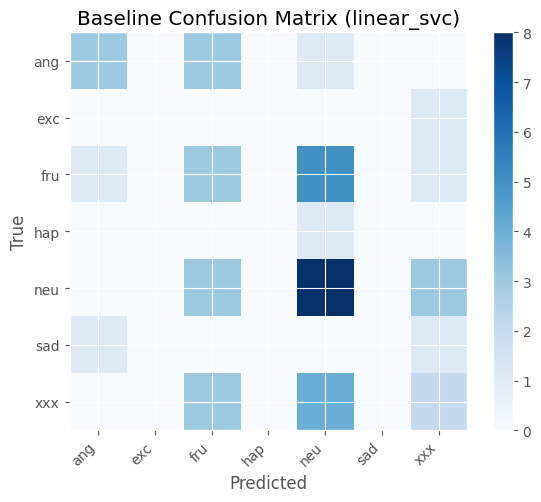

In [5]:
MODEL_SPECS = {
    'logreg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'linear_svc': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=8000)),
    ]),
    'random_forest': Pipeline([
        ('scaler', 'passthrough'),
        ('clf', RandomForestClassifier(
            n_estimators=500,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=RANDOM_FOREST_JOBS,
        )),
    ]),
}

all_labels = np.arange(len(label_enc.classes_))


@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()


def _resolve_model_jobs(requested_jobs: int, n_models: int) -> int:
    if requested_jobs == -1:
        return max(1, min(os.cpu_count() or 1, n_models))
    return max(1, min(int(requested_jobs), n_models))


def _has_inner_parallelism(estimator) -> bool:
    params = estimator.get_params(deep=True)
    if 'clf__n_jobs' not in params:
        return False
    return params['clf__n_jobs'] not in (None, 1)


def _fit_predict_single_model(
    model_name: str,
    estimator,
    X_train_eval,
    y_train_eval,
    X_test_eval,
    y_test_eval,
    stage_name: str,
    force_single_core_inner_model: bool,
):
    model = clone(estimator)

    if force_single_core_inner_model and 'clf__n_jobs' in model.get_params(deep=True):
        model.set_params(clf__n_jobs=1)

    model.fit(X_train_eval, y_train_eval)
    y_pred = model.predict(X_test_eval)

    row = {
        'stage': stage_name,
        'model': model_name,
        'accuracy': accuracy_score(y_test_eval, y_pred),
        'precision_weighted': precision_score(y_test_eval, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test_eval, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_test_eval, y_pred, average='weighted'),
        'f1_macro': f1_score(y_test_eval, y_pred, average='macro'),
    }
    return model_name, row, y_pred


def _evaluate_items_sequential(
    model_items,
    X_train_eval,
    y_train_eval,
    X_test_eval,
    y_test_eval,
    stage_name: str,
    desc: str,
    force_single_core_inner_model: bool,
):
    return [
        _fit_predict_single_model(
            model_name,
            estimator,
            X_train_eval,
            y_train_eval,
            X_test_eval,
            y_test_eval,
            stage_name,
            force_single_core_inner_model,
        )
        for model_name, estimator in tqdm(
            model_items,
            total=len(model_items),
            desc=desc,
            leave=False,
        )
    ]


def _evaluate_items_parallel(
    model_items,
    requested_jobs: int,
    X_train_eval,
    y_train_eval,
    X_test_eval,
    y_test_eval,
    stage_name: str,
    desc: str,
    force_single_core_inner_model: bool,
):
    if not model_items:
        return []

    n_jobs = _resolve_model_jobs(requested_jobs, len(model_items))
    if n_jobs == 1:
        return _evaluate_items_sequential(
            model_items,
            X_train_eval,
            y_train_eval,
            X_test_eval,
            y_test_eval,
            stage_name,
            desc,
            force_single_core_inner_model,
        )

    with tqdm_joblib(tqdm(total=len(model_items), desc=desc, leave=False)):
        return Parallel(n_jobs=n_jobs, backend='loky')(
            delayed(_fit_predict_single_model)(
                model_name,
                estimator,
                X_train_eval,
                y_train_eval,
                X_test_eval,
                y_test_eval,
                stage_name,
                force_single_core_inner_model,
            )
            for model_name, estimator in model_items
        )


def evaluate_models(X_train_eval, y_train_eval, X_test_eval, y_test_eval, stage_name: str):
    model_items = list(MODEL_SPECS.items())
    mode = str(MODEL_PARALLEL_MODE).strip().lower()
    if mode not in {'auto', 'outer', 'sequential'}:
        raise ValueError('MODEL_PARALLEL_MODE must be one of: auto, outer, sequential')

    requested_jobs = _resolve_model_jobs(MODEL_PARALLEL_JOBS, len(model_items))

    if mode == 'sequential' or requested_jobs == 1:
        evaluated = _evaluate_items_sequential(
            model_items,
            X_train_eval,
            y_train_eval,
            X_test_eval,
            y_test_eval,
            stage_name,
            desc=f'{stage_name}: models',
            force_single_core_inner_model=True,
        )
    else:
        if mode == 'outer':
            force_single_core_inner_model = True
        else:
            force_single_core_inner_model = any(_has_inner_parallelism(estimator) for _, estimator in model_items)

        evaluated = _evaluate_items_parallel(
            model_items,
            requested_jobs=requested_jobs,
            X_train_eval=X_train_eval,
            y_train_eval=y_train_eval,
            X_test_eval=X_test_eval,
            y_test_eval=y_test_eval,
            stage_name=stage_name,
            desc=f'{stage_name}: models',
            force_single_core_inner_model=force_single_core_inner_model,
        )

    rows = []
    preds = {}
    for model_name, row, y_pred in evaluated:
        rows.append(row)
        preds[model_name] = y_pred

    metrics_df = pd.DataFrame(rows).sort_values('f1_weighted', ascending=False, ignore_index=True)
    return metrics_df, preds


def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(len(label_enc.classes_)))
    ax.set_yticks(range(len(label_enc.classes_)))
    ax.set_xticklabels(label_enc.classes_, rotation=45, ha='right')
    ax.set_yticklabels(label_enc.classes_)
    plt.tight_layout()
    plt.show()


baseline_results, baseline_preds = evaluate_models(X_train, y_train, X_test, y_test, stage_name='baseline')

print('Baseline metrics (all models):')
print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in tqdm(
    baseline_results['model'],
    total=len(baseline_results),
    desc='baseline: classification reports',
    leave=False,
):
    print(f'\n[{model_name}] classification report (baseline):')
    print(classification_report(
        y_test,
        baseline_preds[model_name],
        labels=all_labels,
        target_names=label_enc.classes_,
        zero_division=0,
    ))

best_baseline_model = baseline_results.loc[0, 'model']
plot_confusion(y_test, baseline_preds[best_baseline_model], f'Baseline Confusion Matrix ({best_baseline_model})')

base_acc = float(baseline_results.loc[0, 'accuracy'])
base_f1 = float(baseline_results.loc[0, 'f1_weighted'])


## 6) TruncatedSVD + Kernel PCA

TF-IDF is high-dimensional, so this cell first compresses it with `TruncatedSVD`, standardizes the dense latent space, then applies nonlinear `KernelPCA`.

Notes:
- the preprojection keeps the computation tractable
- `KernelPCA` captures nonlinear relationships in the dense latent space
- the per-component table uses normalized kernel eigenvalues for component ranking
- the retained variance summary in metadata uses the SVD preprojection variance kept, because Kernel PCA does not expose classical explained variance against the original input space


kernel_pca: fit/transform:   0%|          | 0/6 [00:00<?, ?it/s]

Original feature count: 10480
SVD component count: 172
SVD variance retained: 1.0000
Kernel PCA component count: 172
Decomposition method used: truncated_svd_plus_kernel_pca
KernelPCA component ratios are based on the selected kernel eigenvalues, not classical explained variance on the original TF-IDF space.
Top 10 Kernel PCA components by normalized kernel eigenvalue:
   component  explained_variance_ratio  cumulative_explained_variance  \
0  kpca_0000                  0.025981                       0.025981   
1  kpca_0001                  0.009622                       0.035603   
2  kpca_0002                  0.009083                       0.044686   
3  kpca_0003                  0.008724                       0.053410   
4  kpca_0004                  0.008289                       0.061699   
5  kpca_0005                  0.007533                       0.069233   
6  kpca_0006                  0.007318                       0.076551   
7  kpca_0007                  0.006930      

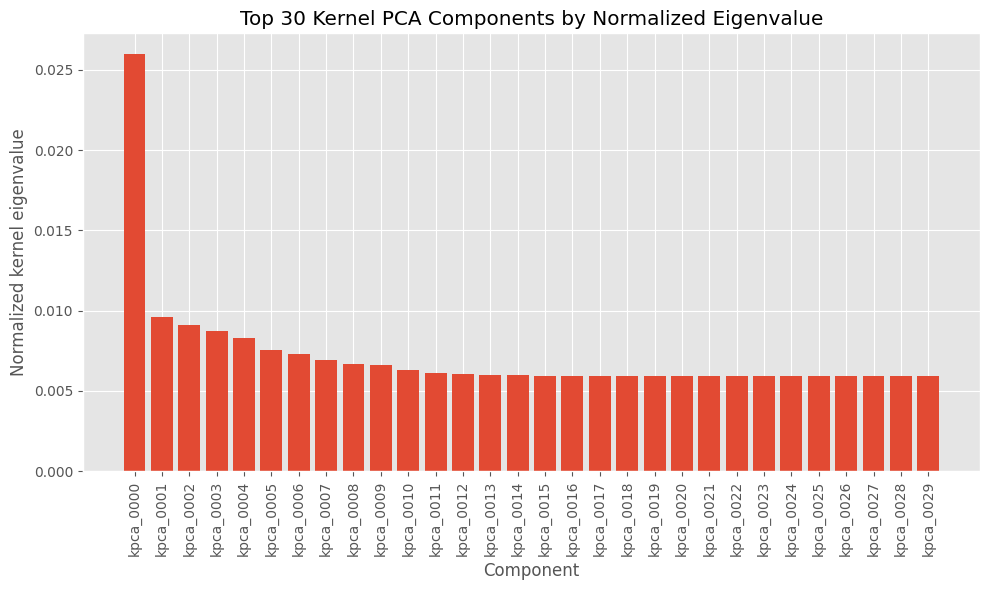

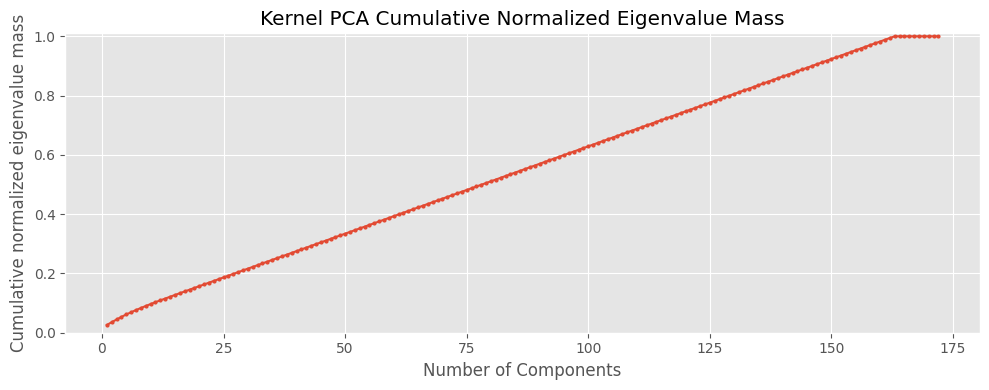

In [6]:
svd_components = resolve_pca_component_count(
    SVD_COMPONENTS,
    n_samples=X_train.shape[0],
    n_features=X_train.shape[1],
)

with tqdm(total=6, desc='kernel_pca: fit/transform', leave=False) as pbar:
    linear_projector = TruncatedSVD(
        n_components=svd_components,
        algorithm='randomized',
        n_iter=7,
        random_state=RANDOM_STATE,
    )
    X_train_linear = linear_projector.fit_transform(X_train)
    pbar.update(2)

    X_test_linear = linear_projector.transform(X_test)
    pbar.update(1)

    latent_scaler = StandardScaler()
    X_train_linear_scaled = latent_scaler.fit_transform(X_train_linear)
    X_test_linear_scaled = latent_scaler.transform(X_test_linear)
    pbar.update(1)

    kpca_components = resolve_pca_component_count(
        KERNEL_PCA_COMPONENTS,
        n_samples=X_train_linear_scaled.shape[0],
        n_features=X_train_linear_scaled.shape[1],
    )
    decomposer = KernelPCA(
        n_components=kpca_components,
        kernel=KERNEL,
        gamma=KERNEL_GAMMA,
        degree=KERNEL_DEGREE,
        coef0=KERNEL_COEF0,
        eigen_solver='auto',
        random_state=RANDOM_STATE,
        n_jobs=RANDOM_FOREST_JOBS,
    )
    X_train_sel = decomposer.fit_transform(X_train_linear_scaled)
    pbar.update(1)

    X_test_sel = decomposer.transform(X_test_linear_scaled)
    pbar.update(1)

component_names = [f'kpca_{i:04d}' for i in range(X_train_sel.shape[1])]
selected_features = component_names

svd_explained = np.asarray(linear_projector.explained_variance_ratio_, dtype=float)
svd_cumulative = np.cumsum(svd_explained)

raw_eigenvalues = getattr(decomposer, 'eigenvalues_', None)
if raw_eigenvalues is None:
    raw_eigenvalues = getattr(decomposer, 'lambdas_', None)
if raw_eigenvalues is None or len(raw_eigenvalues) == 0:
    raise RuntimeError('KernelPCA did not expose eigenvalues after fit.')

eigenvalues = np.asarray(raw_eigenvalues, dtype=float)
explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

print(f'Original feature count: {X_train.shape[1]}')
print(f'SVD component count: {X_train_linear.shape[1]}')
print(f'SVD variance retained: {svd_cumulative[-1]:.4f}')
print(f'Kernel PCA component count: {X_train_sel.shape[1]}')
print(f'Decomposition method used: {DECOMPOSITION_METHOD}')
print('KernelPCA component ratios are based on the selected kernel eigenvalues, not classical explained variance on the original TF-IDF space.')

rank_df = pd.DataFrame({
    'component': component_names,
    'explained_variance_ratio': explained,
    'cumulative_explained_variance': cumulative,
    'kernel_eigenvalue': eigenvalues,
})

print('Top 10 Kernel PCA components by normalized kernel eigenvalue:')
print(rank_df.head(10))

plot_n = min(30, len(rank_df))
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(rank_df['component'][:plot_n], rank_df['explained_variance_ratio'][:plot_n])
ax.set_title(f'Top {plot_n} Kernel PCA Components by Normalized Eigenvalue')
ax.set_xlabel('Component')
ax.set_ylabel('Normalized kernel eigenvalue')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, len(cumulative) + 1), cumulative, marker='o', markersize=2)
ax.set_title('Kernel PCA Cumulative Normalized Eigenvalue Mass')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative normalized eigenvalue mass')
ax.set_ylim(0, 1.01)
plt.tight_layout()
plt.show()


## 7) Model After Kernel PCA

Retrain all baseline models on the nonlinear TF-IDF projection and compare metrics.


kernel_pca: models:   0%|          | 0/3 [00:00<?, ?it/s]

Post-Kernel-PCA metrics (all models):
     stage         model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro
kernel_pca random_forest    0.3182              0.1012           0.3182       0.1536    0.0690
kernel_pca    linear_svc    0.2273              0.1559           0.2273       0.1176    0.0672
kernel_pca        logreg    0.2045              0.1460           0.2045       0.1029    0.0625


kernel_pca: classification reports:   0%|          | 0/3 [00:00<?, ?it/s]


[random_forest] classification report (post-kernel-pca):
              precision    recall  f1-score   support

         ang       0.00      0.00      0.00         7
         exc       0.00      0.00      0.00         1
         fru       0.00      0.00      0.00        10
         hap       0.00      0.00      0.00         1
         neu       0.32      1.00      0.48        14
         sad       0.00      0.00      0.00         2
         xxx       0.00      0.00      0.00         9

    accuracy                           0.32        44
   macro avg       0.05      0.14      0.07        44
weighted avg       0.10      0.32      0.15        44


[linear_svc] classification report (post-kernel-pca):
              precision    recall  f1-score   support

         ang       0.00      0.00      0.00         7
         exc       0.00      0.00      0.00         1
         fru       0.22      0.90      0.35        10
         hap       0.00      0.00      0.00         1
         neu       

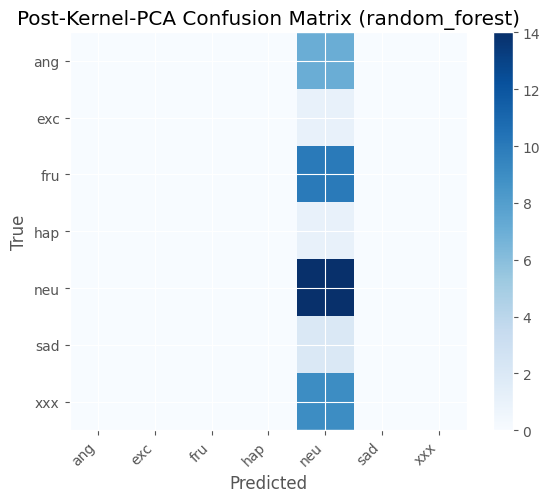


Metric delta by model (Kernel PCA - baseline):
        model  accuracy_baseline  precision_weighted_baseline  recall_weighted_baseline  f1_weighted_baseline  f1_macro_baseline  accuracy_selected  precision_weighted_selected  recall_weighted_selected  f1_weighted_selected  f1_macro_selected  accuracy_delta  precision_weighted_delta  recall_weighted_delta  f1_weighted_delta  f1_macro_delta
random_forest             0.3409                       0.2407                    0.3409                0.2471             0.1285             0.3182                       0.1012                    0.3182                0.1536             0.0690         -0.0227                   -0.1395                -0.0227            -0.0935         -0.0595
   linear_svc             0.3636                       0.3374                    0.3636                0.3439             0.2133             0.2273                       0.1559                    0.2273                0.1176             0.0672         -0.1364     

In [7]:
selected_results, selected_preds = evaluate_models(
    X_train_sel,
    y_train,
    X_test_sel,
    y_test,
    stage_name='kernel_pca',
)

print('Post-Kernel-PCA metrics (all models):')
print(selected_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in tqdm(
    selected_results['model'],
    total=len(selected_results),
    desc='kernel_pca: classification reports',
    leave=False,
):
    print(f'\n[{model_name}] classification report (post-kernel-pca):')
    print(classification_report(
        y_test,
        selected_preds[model_name],
        labels=all_labels,
        target_names=label_enc.classes_,
        zero_division=0,
    ))

best_selected_model = selected_results.loc[0, 'model']
plot_confusion(y_test, selected_preds[best_selected_model], f'Post-Kernel-PCA Confusion Matrix ({best_selected_model})')

comparison_df = baseline_results[['model', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']].merge(
    selected_results[['model', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']],
    on='model',
    suffixes=('_baseline', '_selected'),
)
comparison_df['accuracy_delta'] = comparison_df['accuracy_selected'] - comparison_df['accuracy_baseline']
comparison_df['precision_weighted_delta'] = comparison_df['precision_weighted_selected'] - comparison_df['precision_weighted_baseline']
comparison_df['recall_weighted_delta'] = comparison_df['recall_weighted_selected'] - comparison_df['recall_weighted_baseline']
comparison_df['f1_weighted_delta'] = comparison_df['f1_weighted_selected'] - comparison_df['f1_weighted_baseline']
comparison_df['f1_macro_delta'] = comparison_df['f1_macro_selected'] - comparison_df['f1_macro_baseline']
comparison_df = comparison_df.sort_values('f1_weighted_selected', ascending=False, ignore_index=True)

print('\nMetric delta by model (Kernel PCA - baseline):')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

sel_acc = float(selected_results.loc[0, 'accuracy'])
sel_f1 = float(selected_results.loc[0, 'f1_weighted'])


## 8) Save Artifacts

This exports Kernel PCA component names, kernel eigenvalue ranking, and transformed train/test matrices.


In [8]:
out_dir = artifact_dir
out_dir.mkdir(parents=True, exist_ok=True)

selected_feature_path = out_dir / f'{DATASET_KEY}_pca_components.json'
rank_path = out_dir / f'{DATASET_KEY}_pca_explained_variance.csv'
train_sel_path = out_dir / f'{DATASET_KEY}_X_train_pca.csv'
test_sel_path = out_dir / f'{DATASET_KEY}_X_test_pca.csv'
meta_path = out_dir / f'{DATASET_KEY}_run_metadata.json'

with tqdm(total=8, desc='artifacts: write outputs', leave=False) as pbar:
    with selected_feature_path.open('w', encoding='utf-8') as f:
        json.dump(selected_features, f, indent=2)
    pbar.update(1)

    rank_df.to_csv(rank_path, index=False)
    pbar.update(1)

    X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
    pbar.update(1)

    X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
    pbar.update(1)

    X_train_sel_df.to_csv(train_sel_path, index=False)
    pbar.update(1)

    X_test_sel_df.to_csv(test_sel_path, index=False)
    pbar.update(1)

    baseline_records = baseline_results.to_dict(orient='records')
    selected_records = selected_results.to_dict(orient='records')
    comparison_records = comparison_df.to_dict(orient='records')
    for collection in (baseline_records, selected_records, comparison_records):
        for row in collection:
            for key, value in list(row.items()):
                if isinstance(value, (np.floating, float)):
                    row[key] = float(value)
    pbar.update(1)

    run_meta = {
        'dataset_key': DATASET_KEY,
        'source_dataset_key': SOURCE_DATASET_KEY,
        'source_path': str(source_path),
        'artifact_dir': str(out_dir),
        'target_col': TARGET_COL,
        'machine_name': MACHINE_NAME,
        'include_xxx': bool(INCLUDE_XXX),
        'variant_name': VARIANT_NAME,
        'require_agreement': bool(REQUIRE_AGREEMENT),
        'excluded_emotions': list(EXCLUDED_EMOTIONS),
        'use_variant_artifact_dirs': bool(USE_VARIANT_ARTIFACT_DIRS),
        'rows_loaded': int(rows_loaded),
        'rows_after_filter': int(len(df)),
        'rows_used': int(len(model_df)),
        'original_features': int(X_train.shape[1]),
        'feature_columns_used': int(len(usable_feature_cols)),
        'dropped_feature_columns': int(len(dropped_feature_cols)),
        'classes': list(label_enc.classes_),
        'svd_components_config': SVD_COMPONENTS,
        'svd_components_effective': int(X_train_linear.shape[1]),
        'kernel_pca_components_config': KERNEL_PCA_COMPONENTS,
        'kernel': KERNEL,
        'kernel_gamma': KERNEL_GAMMA,
        'kernel_degree': KERNEL_DEGREE,
        'kernel_coef0': KERNEL_COEF0,
        'decomposition_method': DECOMPOSITION_METHOD,
        'pca_components_effective': int(X_train_sel.shape[1]),
        'pca_explained_variance_total': float(svd_cumulative[-1]),
        'random_state': RANDOM_STATE,
        'test_size': TEST_SIZE,
        'model_parallel_jobs': int(MODEL_PARALLEL_JOBS),
        'model_parallel_mode': MODEL_PARALLEL_MODE,
        'best_baseline_model': str(baseline_results.loc[0, 'model']),
        'best_pca_model': str(selected_results.loc[0, 'model']),
        'baseline_accuracy': float(base_acc),
        'baseline_f1_weighted': float(base_f1),
        'pca_accuracy': float(sel_acc),
        'pca_f1_weighted': float(sel_f1),
        'baseline_model_metrics': baseline_records,
        'pca_model_metrics': selected_records,
        'model_metric_deltas': comparison_records,
    }

    with meta_path.open('w', encoding='utf-8') as f:
        json.dump(run_meta, f, indent=2)
    pbar.update(1)

print('Saved artifacts:')
print('-', selected_feature_path)
print('-', rank_path)
print('-', train_sel_path)
print('-', test_sel_path)
print('-', meta_path)


artifacts: write outputs:   0%|          | 0/8 [00:00<?, ?it/s]

Saved artifacts:
- /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_with_xxx/tfidf_kernel_pca_pca_components.json
- /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_with_xxx/tfidf_kernel_pca_pca_explained_variance.csv
- /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_with_xxx/tfidf_kernel_pca_X_train_pca.csv
- /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_with_xxx/tfidf_kernel_pca_X_test_pca.csv
- /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_with_xxx/tfidf_kernel_pca_run_metadata.json


## 9) Notes for Next Methods

After this nonlinear TF-IDF baseline, useful next steps are:
- tune `KERNEL_GAMMA` / `KERNEL_PCA_COMPONENTS`
- compare against the GPU TF-IDF PCA notebook
- test ANOVA or embedded selection after the nonlinear projection


In [9]:
# Delta summary (Kernel PCA - baseline)
if 'comparison_df' not in globals():
    raise RuntimeError('comparison_df not found. Run the training/evaluation cells first.')

delta_cols = [
    'model',
    'accuracy_baseline',
    'accuracy_selected',
    'accuracy_delta',
    'precision_weighted_baseline',
    'precision_weighted_selected',
    'precision_weighted_delta',
    'recall_weighted_baseline',
    'recall_weighted_selected',
    'recall_weighted_delta',
    'f1_weighted_baseline',
    'f1_weighted_selected',
    'f1_weighted_delta',
    'f1_macro_baseline',
    'f1_macro_selected',
    'f1_macro_delta',
]

delta_table = comparison_df[delta_cols].copy().sort_values('f1_weighted_delta', ascending=False, ignore_index=True)

print('Delta table (Kernel PCA - baseline):')
print(delta_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nDelta accuracy only:')
print(
    delta_table[['model', 'accuracy_baseline', 'accuracy_selected', 'accuracy_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta precision only (weighted):')
print(
    delta_table[['model', 'precision_weighted_baseline', 'precision_weighted_selected', 'precision_weighted_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta recall only (weighted):')
print(
    delta_table[['model', 'recall_weighted_baseline', 'recall_weighted_selected', 'recall_weighted_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta weighted F1 only:')
print(
    delta_table[['model', 'f1_weighted_baseline', 'f1_weighted_selected', 'f1_weighted_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

best_gain_row = delta_table.iloc[0]
print(
    f"\nBest weighted-F1 delta after Kernel PCA: {best_gain_row['model']} | "
    f"Delta F1-weighted={best_gain_row['f1_weighted_delta']:+.4f}, "
    f"Delta Accuracy={best_gain_row['accuracy_delta']:+.4f}"
)


Delta table (Kernel PCA - baseline):
        model  accuracy_baseline  accuracy_selected  accuracy_delta  precision_weighted_baseline  precision_weighted_selected  precision_weighted_delta  recall_weighted_baseline  recall_weighted_selected  recall_weighted_delta  f1_weighted_baseline  f1_weighted_selected  f1_weighted_delta  f1_macro_baseline  f1_macro_selected  f1_macro_delta
random_forest             0.3409             0.3182         -0.0227                       0.2407                       0.1012                   -0.1395                    0.3409                    0.3182                -0.0227                0.2471                0.1536            -0.0935             0.1285             0.0690         -0.0595
       logreg             0.2955             0.2045         -0.0909                       0.2177                       0.1460                   -0.0717                    0.2955                    0.2045                -0.0909                0.2409                0.1029     